# Machine Learning Classifier for Lung Disease
## K-Nearest Neighbors (KNN)

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib

In [2]:
def load_lung_disease_dataset(base_path, img_size=(224, 224)):
    data = []
    labels = []
    
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} not found.")
        return None, None
        
    class_names = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for idx, label in enumerate(class_names):
        folder_path = os.path.join(base_path, label)
        files = os.listdir(folder_path)
        
        for img_name in tqdm(files, desc=f"Loading {label}", leave=False):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            img = clahe.apply(img)
            img = cv2.resize(img, img_size)
            
            # Flattening 224x224 results in an array of 50,176 features per image
            data.append(img.flatten() / 255.0)
            labels.append(idx)
            
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int32)

### Load Data set

In [ ]:
X, y = load_lung_disease_dataset('1/dataset_combined')

### Split Dataset
- Three-Way Split (Train 70%, Val 15%, Test 15%)

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Val shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(6448, 50176), y=(6448,)
Val shapes: X=(1378, 50176), y=(1378,)
Test shapes: X=(1382, 50176), y=(1382,)


### Hyperparameter Tuning (Grid Search)

In [9]:
n_neighbors_list = [3, 5, 7, 9, 11, 13, 15]
weights_list = ['uniform', 'distance']

best_val_acc = -1
best_params = {}
best_knn_model = None

print(f"\nStarting Grid Search on {len(n_neighbors_list) * len(weights_list)} combinations...")

for weights in weights_list:
    for n in n_neighbors_list:
       
        model = KNeighborsClassifier(n_neighbors=n, weights=weights, n_jobs=-1) 
        model.fit(X_train, y_train)
        
        val_accuracy = model.score(X_val, y_val) * 100
        
        print(f"Tested -> Neighbors: {n}, Weights: {weights} | Val Acc: {val_accuracy:.2f}%")
        
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_params = {'n_neighbors': n, 'weights': weights}
            best_knn_model = model

print(f"\nBest Parameters: {best_params} with {best_val_acc:.2f}% Validation Accuracy.")


Starting Grid Search on 14 combinations...
Tested -> Neighbors: 3, Weights: uniform | Val Acc: 77.72%
Tested -> Neighbors: 5, Weights: uniform | Val Acc: 79.54%
Tested -> Neighbors: 7, Weights: uniform | Val Acc: 79.32%
Tested -> Neighbors: 9, Weights: uniform | Val Acc: 80.91%
Tested -> Neighbors: 11, Weights: uniform | Val Acc: 80.99%
Tested -> Neighbors: 13, Weights: uniform | Val Acc: 80.55%
Tested -> Neighbors: 15, Weights: uniform | Val Acc: 80.41%
Tested -> Neighbors: 3, Weights: distance | Val Acc: 82.00%
Tested -> Neighbors: 5, Weights: distance | Val Acc: 84.33%
Tested -> Neighbors: 7, Weights: distance | Val Acc: 84.40%
Tested -> Neighbors: 9, Weights: distance | Val Acc: 85.12%
Tested -> Neighbors: 11, Weights: distance | Val Acc: 84.33%
Tested -> Neighbors: 13, Weights: distance | Val Acc: 84.76%
Tested -> Neighbors: 15, Weights: distance | Val Acc: 84.76%

Best Parameters: {'n_neighbors': 9, 'weights': 'distance'} with 85.12% Validation Accuracy.



Evaluating best model on unseen Test Set...
Final Test Accuracy: 82.85%


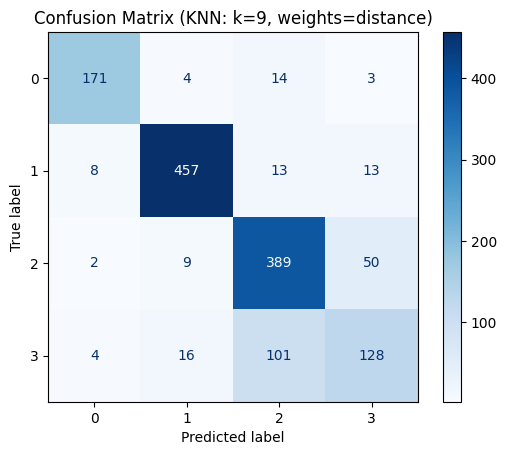


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       192
           1       0.94      0.93      0.94       491
           2       0.75      0.86      0.80       450
           3       0.66      0.51      0.58       249

    accuracy                           0.83      1382
   macro avg       0.82      0.80      0.81      1382
weighted avg       0.83      0.83      0.82      1382

Model saved successfully as 'best_knn_lung_disease_model.pkl'


In [11]:
print("\nEvaluating best model on unseen Test Set...")
final_accuracy = best_knn_model.score(X_test, y_test) * 100
print(f'Final Test Accuracy: {final_accuracy:.2f}%')

y_pred = best_knn_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (KNN: k={best_params['n_neighbors']}, weights={best_params['weights']})")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

joblib.dump(best_knn_model, "best_knn_lung_disease_model.pkl")
print("Model saved successfully as 'best_knn_lung_disease_model.pkl'")